In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 演習問題2.1

In [2]:
data = {
    "Treatment": [4.81, 4.17, 4.41, 3.59, 5.87, 3.83, 6.03, 4.98, 4.90, 5.75, 5.36, 3.48, 4.69, 4.44, 4.89, 4.71, 5.48, 4.32, 5.15, 6.34],
    "Control":   [4.17, 3.05, 5.18, 4.01, 6.11, 4.10, 5.17, 3.57, 5.33, 5.59, 4.66, 5.58, 3.66, 4.50, 3.90, 4.61, 5.62, 4.53, 6.05, 5.14]
}
df_2_8 = pd.DataFrame(data)

In [3]:
df_2_8

,Treatment,Control
0,4.81,4.17
1,4.17,3.05
2,4.41,5.18
3,3.59,4.01
4,5.87,6.11
5,3.83,4.10
6,6.03,5.17
7,4.98,3.57
8,4.90,5.33
9,5.75,5.59


## (a)

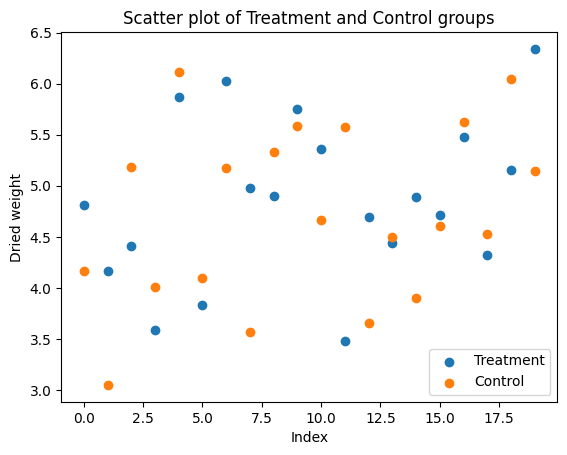

In [4]:
plt.figure()
plt.scatter(range(len(df_2_8)), df_2_8["Treatment"], label="Treatment")
plt.scatter(range(len(df_2_8)), df_2_8["Control"], label="Control")
plt.xlabel("Index")
plt.ylabel("Dried weight")
plt.title("Scatter plot of Treatment and Control groups")
plt.legend()
plt.savefig("test.png")
plt.show()

In [5]:
df_2_8.describe()

,Treatment,Control
count,20.000000,20.000000
mean,4.860000,4.726500
std,0.790922,0.863526
min,3.480000,3.050000
25%,4.387500,4.077500
50%,4.850000,4.635000
75%,5.390000,5.392500
max,6.340000,6.110000


## (b)

In [6]:
from scipy.stats import t

# 各群における平均と分散
mean_treatment = df_2_8.mean().values[0]
mean_control = df_2_8.mean().values[1]
var_treatment = df_2_8.var(ddof = 1).values[0]
var_control = df_2_8.var(ddof = 1).values[1]

# poolした分散
pooled_variance = ((len(df_2_8) - 1) * var_treatment + (len(df_2_8) - 1) * var_control) / (len(df_2_8) + len(df_2_8) - 2)

# t値
t_value = (mean_treatment - mean_control)/np.sqrt(pooled_variance * (1/len(df_2_8) + 1/len(df_2_8)))

# 自由度
freedom = len(df_2_8) + len(df_2_8) - 2

# 95%信頼区間なので
alpha = 0.025
t_crit = t.ppf(1 - alpha, freedom)

# 群の平均の差
diff = mean_treatment - mean_control

# 標準誤差
se = np.sqrt(pooled_variance * (1/len(df_2_8) + 1/len(df_2_8)))

# 信頼区間
ci_low = diff - t_crit * se
ci_high = diff + t_crit * se

In [15]:
t_value

np.float64(0.5098476266071734)

In [16]:
freedom

38

In [17]:
diff

np.float64(0.1335000000000015)

In [18]:
ci_low

np.float64(-0.39657331363038195)

In [19]:
ci_high

np.float64(0.663573313630385)

## (c)

In [23]:
# 対立仮説の場合
df_2_8.mean()

Treatment    4.8600
Control      4.7265
dtype: float64

In [29]:
# 帰無仮説の場合
df_2_8.sum().sum() / (df_2_8.shape[0]*df_2_8.shape[1])

np.float64(4.7932500000000005)

## (d)

In [31]:
df_2_8

,Treatment,Control
0,4.81,4.17
1,4.17,3.05
2,4.41,5.18
3,3.59,4.01
4,5.87,6.11
5,3.83,4.10
6,6.03,5.17
7,4.98,3.57
8,4.90,5.33
9,5.75,5.59


In [33]:
df_2_8.mean()

Treatment    4.8600
Control      4.7265
dtype: float64

In [36]:
((df_2_8 - df_2_8.mean())**2).sum().sum()

np.float64(26.053455)

In [43]:
y_bar = df_2_8.sum().sum() / (df_2_8.shape[0]*df_2_8.shape[1])
((df_2_8 - y_bar)**2).sum().sum()

np.float64(26.231677500000004)

In [46]:
S_0 = ((df_2_8 - df_2_8.sum().sum() / (df_2_8.shape[0]*df_2_8.shape[1]))**2).sum().sum()
S_1 = ((df_2_8 - df_2_8.mean())**2).sum().sum()
F = (S_0 - S_1) / (S_1/38)

In [49]:
0.5098476266071734**2

0.25994460235696776

In [48]:
F

np.float64(0.2599446023569676)